## **Overview**

This section provides an overview of how to access digiLab's Uncertainty Engine via the Software Development Kit (SDK). As an alternative to the Graphical User Interface (GUI), the SDK is designed for users who are comfortable writing in Python and would prefer to use a notebook to interact with the Uncertainty Engine.

The SDK can also offer a number of advantages, including:

- Ease of **automated resource integration** (i.e., a simple Python script can be written to navigate on-device directories)
- Freedom of **bespoke visualisation** of Uncertainty Engine outputs
- Efficiency of looping **repetitive tasks** (e.g., running a model training workflow - varying the model configuration each iteration)
- Traceability of **version control**, to manage collaborative projects (using git)

Datasets used in workflows executed via the SDK are ultimately stored within a project space as a resource. The workflows themselves (e.g., train classifier) and the product of workflows (e.g., a GP regressor model) can be saved to project spaces via the SDK. This is reflected in the Uncertainty Engine front-end (i.e. the GUI), which can be incredibly useful for showcasing complex workflows to stakeholders with a range of technical proficiency.

In [1]:
# Import libraries
from dotenv import load_dotenv
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pprint import pprint
from io import BytesIO, StringIO
import requests
from pprint import pprint

from uncertainty_engine import Client, Environment

# Import core UE classes
from uncertainty_engine.graph import Graph
from uncertainty_engine.nodes.workflow import Workflow
from uncertainty_engine.nodes.base import Node

# Define colours for plotting
KEY_LIME = "#EBF38B"
INDIGO = "#16425B"
INDIGO_50 = "#8AA0AD"
KEPPEL = "#16D5C2"
KEPPEL_50 = "#8AEAE1"
BLACK = "#000000"
GREY_80 = "#333333"
LIGHT_GREY = "#CCCCCC"
WHITE = "#FFFFFF"

In [ ]:
load_dotenv()

# Option 1: Standard Environment Set-up

# client = Client()
# client.authenticate()

#####################################

# Option 2: Custom Environment Set-up

env=Environment(
    cognito_user_pool_client_id=os.environ["cognito_user_pool_client_id"],
    core_api=os.environ["core_api"],
    region=os.environ["region"],
    resource_api=os.environ["resource_api"]
)

client = Client(env=env)
client.authenticate()

In [3]:
# List projects that exist in your UE environment
# This is good sanity check to ensure you are in the right environment
client.projects.list_projects()

[ProjectRecordOutput(id='69ef3a63e9dad5bb29c30db7', name='Personal', owner_id='69ef3a62e9dad5bb29c30db6', description=None, members={}, created_at=datetime.datetime(2026, 4, 27, 10, 28, 51), updated_at=datetime.datetime(2026, 4, 27, 10, 28, 51)),
 ProjectRecordOutput(id='69f071ae14e9a5c7134611ad', name='Example', owner_id='69ef3a62e9dad5bb29c30db6', description=None, members={}, created_at=datetime.datetime(2026, 4, 28, 8, 37, 2), updated_at=datetime.datetime(2026, 4, 28, 8, 37, 2)),
 ProjectRecordOutput(id='69f0880414e9a5c7134611fc', name='FE Example', owner_id='69ef3a62e9dad5bb29c30db6', description=None, members={}, created_at=datetime.datetime(2026, 4, 28, 10, 12, 20), updated_at=datetime.datetime(2026, 4, 28, 10, 12, 20)),
 ProjectRecordOutput(id='69fa11b1e86013feaf2ae42d', name='SDKExample', owner_id='69ef3a62e9dad5bb29c30db6', description=None, members={}, created_at=datetime.datetime(2026, 5, 5, 15, 50, 9), updated_at=datetime.datetime(2026, 5, 5, 15, 50, 9))]

In [4]:
# Currently, projects must be created via the Uncertainty Engine GUI
# Enter the project name here:
PROJECT_NAME = "SDKExample"  # e.g. "SDKExample"
project_id = client.projects.get_project_id_by_name(PROJECT_NAME)

In [ ]:
# OPTIONAL: Detail node info

# 1. See all nodes
pprint(client.list_nodes())

# 2. Look at specific node
# node_name="ModelConfig"
# pprint(client.get_node_info(node_name, version=""))

### **Problem Introduction**

##### You are a gold miner and would like to understand how the concentration of gold varies with position. Sample extraction is very costly, so you'd like to determine this position with as few samples as possible. You would also like to know how certain you are about how the gold concentration is distributed - given the samples you have taken so far.

#### **1. Define the "Ground Truth" and take initial samples**

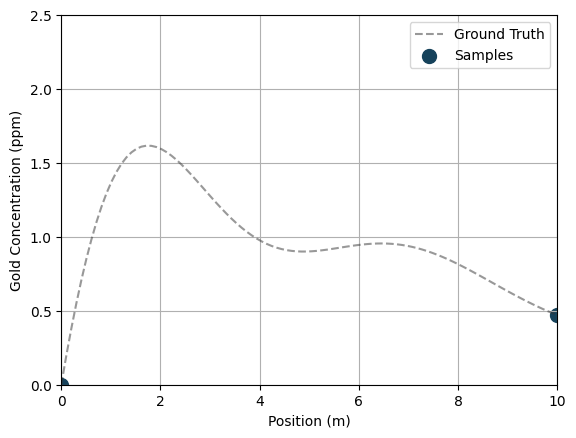

In [7]:
# Define bounds of input space and output space of interest
x_bounds = [0, 10]
y_bounds = [0, 2.5]

# Define a ground truth - i.e., the underlying relationship that we're looking to uncover from a selection of samples
def ground_truth(x, noise=False):

    """

        Defines a ground truth that is smooth, but has some non-trivial features.
        There is the option to add noise to this ground truth for the purposes of reflecting realistic sampling

    """

    def f(x):
        """

            Define the ground truth function - this can be changed in desired.

        """
        return (np.sin(x) + x) * np.exp(-0.3 * x)

    if noise:
        y = f(x) + np.random.normal(0, 0.05, size=x.shape)
    else:
        y = f(x)

    return y

# Generate the ground truth values for plotting
gt_x = np.linspace(x_bounds[0], x_bounds[1], 100)
gt_y = ground_truth(gt_x)

# Take a small number of samples - it is expensive, both in time and cost, to take a sample.
# The bounds of our input space are chosen as our initial samples
samples_x = np.array([x_bounds[0], x_bounds[1]])
samples_y = ground_truth(samples_x, noise=False)


# Plot the ground truth - i.e., the relationship we're trying to find
plt.plot(gt_x, gt_y, label="Ground Truth", alpha=0.5, linestyle="--", color=GREY_80)

# Plot the initial samples (at the extremities of the input space)
plt.scatter(samples_x, samples_y, label="Samples", color=INDIGO, s=100)

# Format the plot
plt.xlabel("Position (m)")
plt.ylabel("Gold Concentration (ppm)")
plt.grid()
plt.xlim(x_bounds)
plt.ylim(y_bounds)
plt.legend()
plt.show()


#### **2. Approach to uncovering the gold concentration distribution**

We ultimately want to choose subsequent samples that minimise our global uncertainty / maximise the information gain

##### The approach will involve the following steps:
1. Train a Gaussian Process Regressor (probabilistic ML model) on the sample data available
2. Visualise how the model predicts across the input space (position) and how the uncertainty varies (uncertainty quantification)
3. Using an Active Learning technique, select the most suitable next sample position for efficient information gain
4. Extension: *Repeat steps 1-3 until the sample budget is expended*

##### Throughout this example - workflows will be constructed to showcase many of the core UE functions:
- Model Training
- Model Prediction
- Sample Recommendation (Active Learning)

NB: All project resources (models and datasets) are saved and reflected in the UE GUI

#### **3. Upload Resources**

In [8]:
# Create a data folder if it doesn't already exist
# This simply acts as an intermediary for resource upload
if not os.path.exists("data"):
    os.makedirs("data")

iteration = 1

# Save sample data as csvs
df = pd.DataFrame(samples_x, columns=["x"])
df.to_csv(f"data/x_train{iteration}.csv", index=False)

df = pd.DataFrame(samples_y, columns=["y"])
df.to_csv(f"data/y_train{iteration}.csv", index=False)

# It is useful to upload an input space dataset.
# This is what we ultimately make predictions on to visualise the models that will be trained
input_space = np.linspace(x_bounds[0], x_bounds[1], 100)
input_space_df = pd.DataFrame(input_space, columns=["x"])
input_space_df.to_csv("data/input_space.csv", index=False)


# Define resource names
resource_names = [f"x_train{iteration}", f"y_train{iteration}", "input_space"]

for resource_name in resource_names:

    # Resources cannot be directly overwritten
    # If a resource with the same name already exists, we delete it before uploading the new resource
    try:
        existing_resource_id = client.resources.get_resource_id_by_name(
            resource_type="dataset",
            project_id=project_id,
            name=resource_name,
        )

        client.resources.delete_resource(
            project_id=project_id,
            resource_type="dataset",
            resource_id=existing_resource_id,
        )

        print(
            f'Deleted existing resource "{resource_name}" with ID {existing_resource_id}'
        )

    except:

        print(
            f'No existing resource named "{resource_name}" found. Proceeding to upload.'
        )

# For resource upload, we need to specify resource locations
resource_locs = [f"data/x_train{iteration}.csv", f"data/y_train{iteration}.csv", "data/input_space.csv"]

# Upload the datasets as resources to the UE project
for resource_name, file_path in zip(resource_names, resource_locs):
    resource_id = client.resources.upload(
        project_id=project_id,
        name=resource_name,
        file_path=file_path,
        resource_type="dataset",
    )

    print(f'Uploaded {file_path} as resource "{resource_name}"')

No existing resource named "x_train1" found. Proceeding to upload.
No existing resource named "y_train1" found. Proceeding to upload.
No existing resource named "input_space" found. Proceeding to upload.
Uploaded data/x_train1.csv as resource "x_train1"
Uploaded data/y_train1.csv as resource "y_train1"
Uploaded data/input_space.csv as resource "input_space"


----------------------
##### *Workflow Explainer:*
- A workflow begins with the creation of a **Graph** object, which serves as the backbone of the entire process. Nodes are then added to this graph.
- Each node encapsulates a specific function, such as loading a dataset, configuring a model, training the model, or saving the object(s).
- The workflow itself is not fully defined until the graph is wrapped within a **Workflow** object.
- Once instantiated, the **Workflow** object can be executed to run the defined sequence of functions (i.e., nodes).
##
----------------------

#### **4. Build a Gaussian Process Regressor (Train Example)**

In [9]:
# NB: We wrap the workflow construction and execution in a function for ease of subsequent iteration
def train_model(client, project_id, iteration):

    """

        Train a GP regressor on sample data available in the iteration.

    """

    # The graph is the backbone of our "TRAIN' workflow - essentially stitching together each of the nodes that will be created
    train_graph = Graph()

    # Resources are referenced by their id, not name.
    # We can deduce the ids of the relevant resources as follows
    x_train_id = client.resources.get_resource_id_by_name(
        resource_type="dataset",
        project_id=project_id,
        name=f"x_train{iteration}"
    )
    y_train_id = client.resources.get_resource_id_by_name(
        resource_type="dataset",
        project_id=project_id,
        name=f"y_train{iteration}",
    )


    # Create a model configuration node (ModelConfig)
    # In this case, configuration is kept to the default regressor
    model_config = Node(
        node_name="ModelConfig",   # the type of node being created
        label="Model Config",      # the nodes label (needs to be unique in the graph)
        version="0.5.0",           # the version of the node to be used
        client=client,
    )

    # Create a load dataset node for the x training data (LoadDataset)
    X_train = Node(
        node_name="LoadDataset",   # the type of node being created
        label="Load Train X",      # the nodes label (needs to be unique in the graph)
        version="0.5.0",           # the version of the node to be used
        project_id=project_id,     # the project id where the resource is located
        file_id={"id":x_train_id}, # the resource id of the file you want to load
        client=client,
    )

    # Create a load dataset node for the y training data (LoadDataset)
    y_train = Node(
        node_name="LoadDataset",   # the type of node being created
        label="Load Train Y",      # the nodes label (needs to be unique in the graph)
        version="0.5.0",           # the version of the node to be used
        project_id=project_id,     # the project id where the resource is located
        file_id={"id":y_train_id}, # the resource id of the file you want to load
        client=client,
    )

    # Add each of the nodes created to the graph
    train_graph.add_node(model_config)
    train_graph.add_node(X_train)
    train_graph.add_node(y_train)

    # Create handles for the configuration and loaded dataset files
    # This essentially allows node outputs to be mapped to the inputs of subsequent nodes
    output_config = model_config.make_handle("config")
    x_handle = X_train.make_handle("file")
    y_handle = y_train.make_handle("file")

    # Create the train model node (TrainModel)
    train_model = Node(
        node_name="TrainModel",
        label="Train Model",
        version="0.7.0",
        config=output_config,
        inputs=x_handle,
        outputs=y_handle,
        client=client,
    )

    # Denote the current iteration for the Gold Concentration Regressor model to be trained
    model_name = f"gc_regressor{iteration}"

    # Create a node to save the model, once trained (Save)
    # When the workflow is created and executed containing this node; the trained model is then saved as a resource within the project
    save_model = Node(
        node_name="Save",
        label="Save Model",
        version="0.4.0",
        data=train_model.make_handle("model"),
        project_id=project_id,
        file_id=model_name,
        client=client,
    )

    # Add the new nodes to the graph
    train_graph.add_node(train_model)
    train_graph.add_node(save_model)

    # The graph (with nodes attached) is wrapped in a workflow as follows.
    # It is the workflow that is ultimately executed to train the model
    train_workflow = Workflow(
        graph=train_graph.nodes,
        inputs=train_graph.external_input,
        external_input_id=train_graph.external_input_id,
        client=client
    )

    # This executes the workflow defined and saves the trained model to the project workspace (for subsequent prediction)
    train_response = client.run_node(train_workflow)

    # Error handling
    # Inspection of the execution reponse can uncover the source of the failure if the workflow did not execute successfully
    result = train_response.status.value == "completed"
    if not result:
        pprint(train_response.model_dump())

    assert train_response.status.value == "completed"

    print("Training complete of " + str(model_name))

    return train_workflow


# Train model for first iteration
train_workflow = train_model(
    client=client,
    project_id=project_id,
    iteration=iteration,
)

# Save this workflow (and showcase parity with the UE GUI)
train_workflow_id = client.workflows.save(
      project_id=project_id,
      workflow=train_workflow,
      workflow_name="TrainGPRegressor",
  )

Training complete of gc_regressor1


The workflow `train_workflow` (aliased as TrainGPRegressor) will be reflected in the UE application:

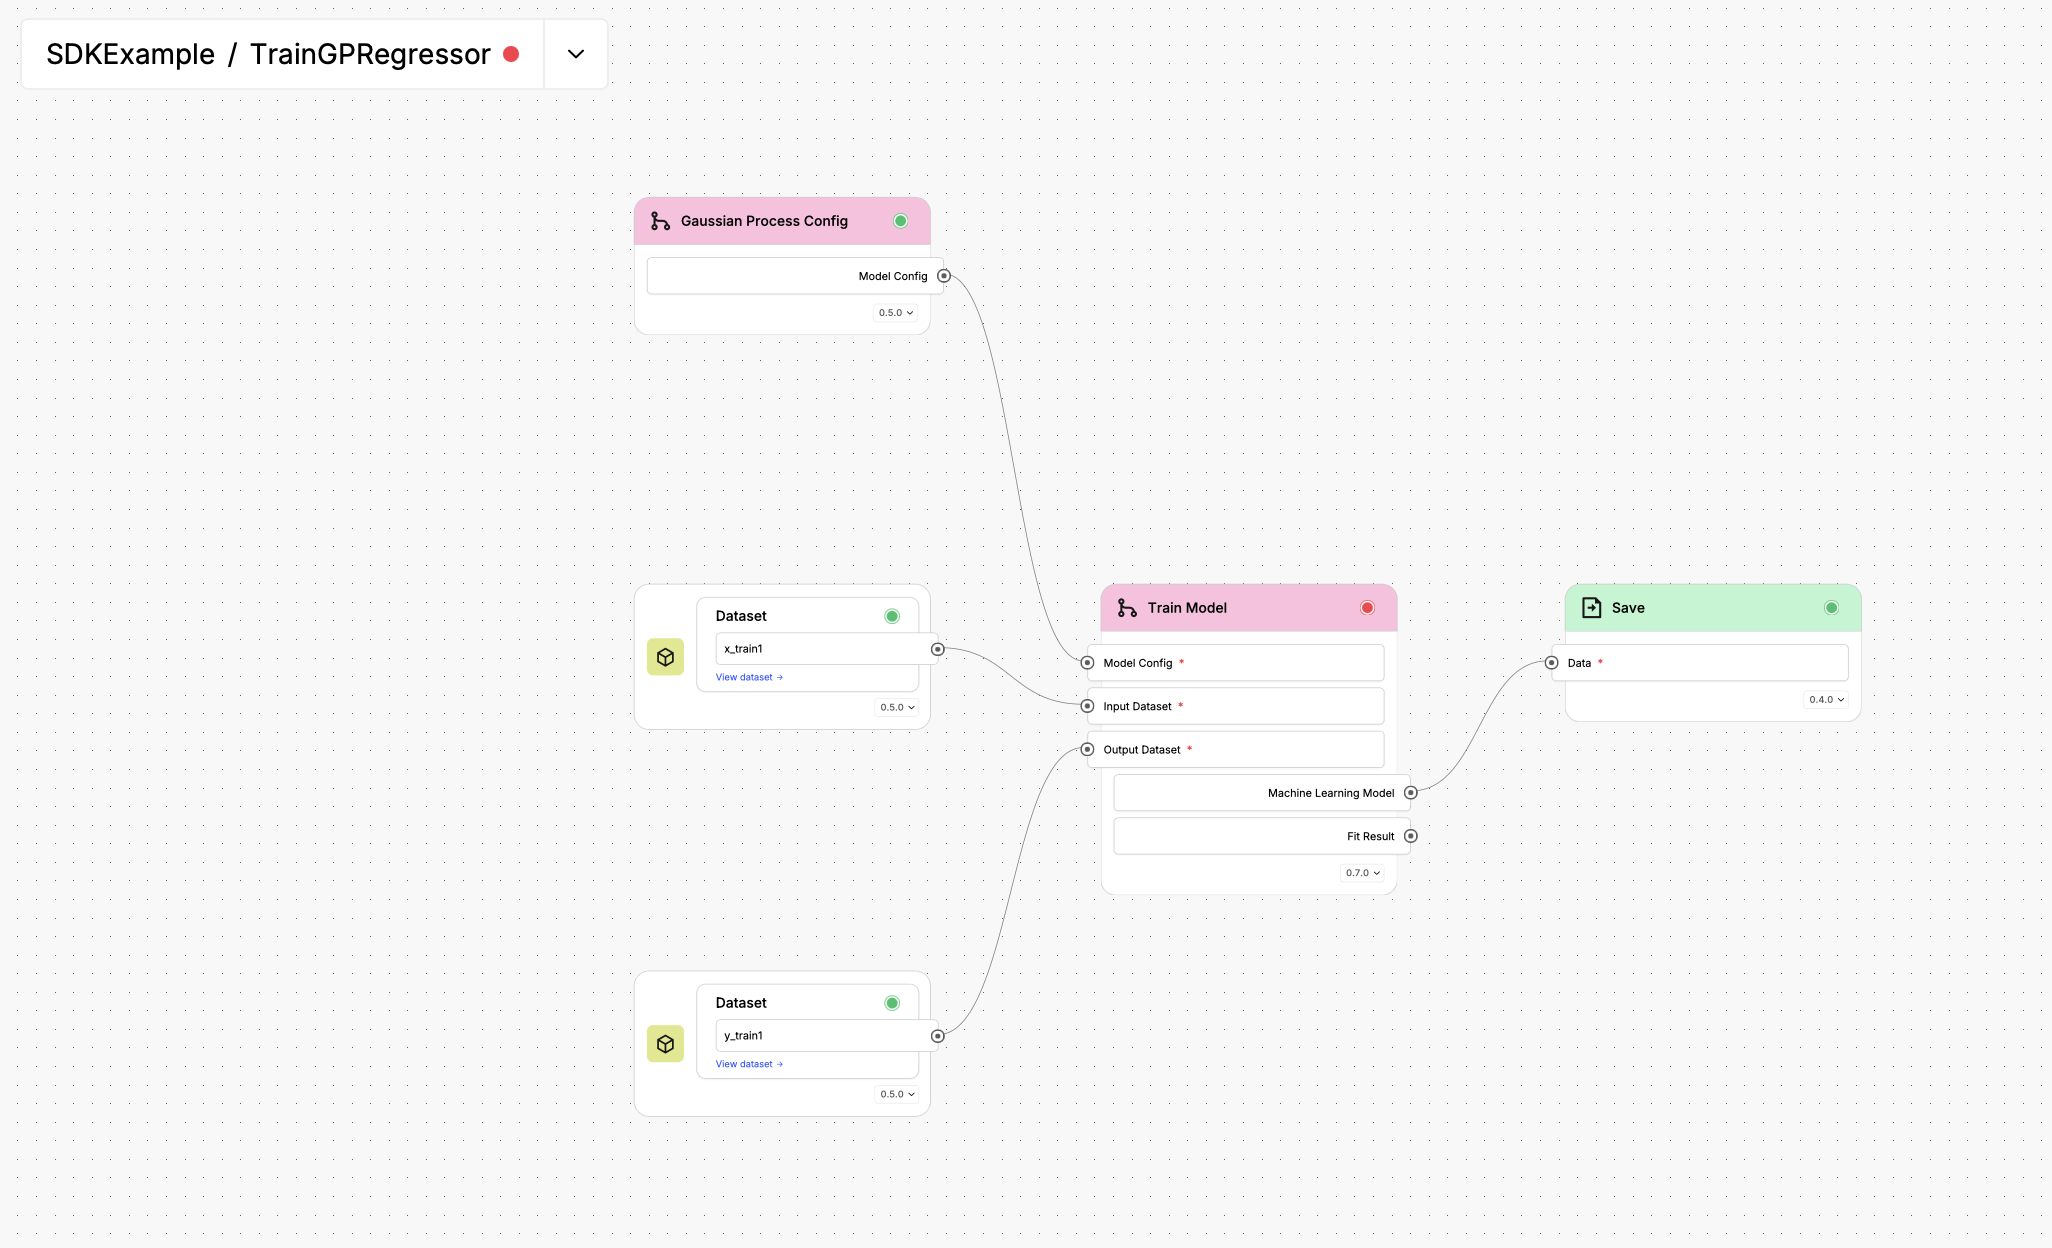

#### **5. Visualise the Model & Uncertainty Quantification (Predict Example)**

#### 5.1 Make Prediction Datasets

In [10]:
def create_visualise_dataset(client, project_id, iteration):

    """

        Make predictions over the entire input space, for the purposes of visualisation

    """


    # Create a predict graph - the backbone of the predict workflow
    predict_graph = Graph()

    # Select the relevant model name for the iteration
    model_name = f"gc_regressor{iteration}"

    # Find the model ID corresponding to the model name
    for model in client.resources.list_resources(project_id=project_id, resource_type="model"):
        if model.name == model_name:
            break  # Stop after finding the first match. We can use the model ID for future reference

    # Find the resource ID for the input space dataset
    input_space_id = client.resources.get_resource_id_by_name(
        resource_type="dataset",
        project_id=project_id,
        name="input_space",
    )

    # Create node to load the model (using model ID)
    load_model = Node(
        node_name="LoadModel",
        label="Load Model",
        version="0.4.0",
        project_id=project_id,
        file_id={"id": model.id},
        client=client,
    )

    input_space = Node(
        node_name="LoadDataset",
        label="Input Space",
        version="0.5.0",
        project_id=project_id,
        file_id={"id": input_space_id},
        client=client,
    )

    predict = Node(
        node_name="PredictModel",
        label="Predict Model",
        version="0.5.0",
        dataset= input_space.make_handle("file"),
        model=load_model.make_handle("file"),
        client=client,
    )

    # Add handles to the prediction and uncertainty outputs
    output_predictions = predict.make_handle("prediction")
    output_uncertainty = predict.make_handle("uncertainty")

    # Define download nodes for predictions and uncertainty
    save_predictions = Node(
        node_name="Save",
        label="Save Predictions",
        version="0.4.0",
        data=output_predictions,
        file_id=f"mean_{iteration}",
        project_id=project_id,
        client=client,
    )

    save_uncertainty = Node(
        node_name="Save",
        label="Save Uncertainty",
        version="0.4.0",
        data=output_uncertainty,
        file_id=f"std_{iteration}",
        project_id=project_id,
        client=client,
    )

    predict_graph.add_node(load_model)
    predict_graph.add_node(input_space)
    predict_graph.add_node(predict)
    predict_graph.add_node(save_predictions)
    predict_graph.add_node(save_uncertainty)

    predict_workflow = Workflow(
        graph=predict_graph.nodes,
        inputs=predict_graph.external_input,
        external_input_id=predict_graph.external_input_id,
        client=client,
    )

    # Execute the prediction workflow
    predict_response = client.run_node(predict_workflow)

    # Error handling

    result = predict_response.status.value == "completed"

    if not result:
        pprint(predict_response.model_dump())

    assert predict_response.status.value == "completed"


    return predict_workflow

# Make predictions for visualisation for first iteration
predict_workflow = create_visualise_dataset(
    client=client,
    project_id=project_id,
    iteration=iteration,
)


# Save this workflow (and showcase parity with the UE application)
predict_workflow_id = client.workflows.save(
    project_id=project_id,
    workflow=predict_workflow,
    workflow_name="PredictForUQ",
)


#### 5.2 Visualise Predictions (Fit & Uncertainty Quantification)

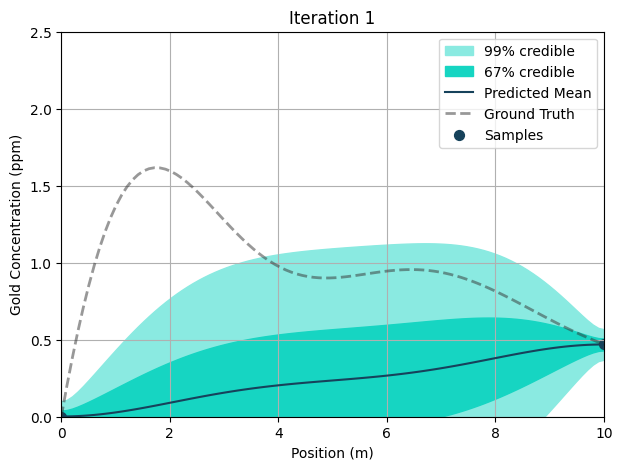

In [11]:
def plot_model_uncertainty(samples_x, samples_y, visualise_means, visualise_stds, visualise_inputs, iteration: int, y_bounds, with_ground_truth=True):

    """

        Plot the posterior mean and shaded plots of 67% and 99% credible intervals.
        Overlay ground truth (optional) and samples available.

    """

    # Ensure that the data is the right shape

    samples_x=samples_x.to_numpy().flatten()
    samples_y=samples_y.to_numpy().flatten()
    visualise_means=visualise_means.to_numpy().flatten()
    visualise_stds=visualise_stds.to_numpy().flatten()
    visualise_inputs=visualise_inputs.to_numpy().flatten()


    # Once again, compute the ground truth for comparison
    gt_y = ground_truth(visualise_inputs, noise=False)

    # Credible interval std multipliers
    z67 = 1.0
    z99 = 2.576

    lower67 = visualise_means - z67 * visualise_stds
    upper67 = visualise_means + z67 * visualise_stds

    lower99 = visualise_means - z99 * visualise_stds
    upper99 = visualise_means + z99 * visualise_stds

    plt.figure(figsize=(7,5))

    # 1) Plot the credible intervals as shaded regions
    plt.fill_between(visualise_inputs, lower99, upper99, label="99% credible", color=KEPPEL_50)
    plt.fill_between(visualise_inputs, lower67, upper67, label="67% credible", color=KEPPEL)

    # 2) Plot the predicted (posterior mean) - this is the fit, essentially
    plt.plot(visualise_inputs, visualise_means, label='Predicted Mean', color=INDIGO)

    # 3) Only plot the ground truth if selected (selected by default)
    if with_ground_truth:
        plt.plot(visualise_inputs, gt_y, linewidth=2, label="Ground Truth", color=GREY_80, linestyle='--', alpha=0.5)

    # 4) Plot the samples available for training the model
    plt.scatter(samples_x, samples_y, label="Samples", s=50, color=INDIGO)

    plt.legend(loc="upper right")
    plt.grid()
    plt.title(f"Iteration {iteration}")
    plt.xlabel("Position (m)")
    plt.ylabel("Gold Concentration (ppm)")
    plt.xlim(x_bounds)
    plt.ylim(y_bounds)

    if with_ground_truth:

        fig_name = "uncertainty_plot_" + str(iteration) + "_gt_overlayed"

    else:

        fig_name = "uncertainty_plot_" + str(iteration)

    plt.savefig(fig_name + ".png")
    plt.show()

def get_dataset(client, resource_name, project_name):

    """

        With only the resource name, returns dataset as a pandas DataFrame


    """

    dataset = client.resources.download(
        resource_id=client.resources.get_resource_id_by_name(
            name=resource_name,
            resource_type="dataset",
            project_id=client.projects.get_project_id_by_name(project_name),
        ),
        project_id=client.projects.get_project_id_by_name(project_name),
        resource_type="dataset",
    )

    return pd.read_csv(BytesIO(dataset))

# Get the datasets from the Uncertainty Engine for visualisation
samples_x = get_dataset(client, f"x_train{iteration}", PROJECT_NAME)
samples_y = get_dataset(client, f"y_train{iteration}", PROJECT_NAME)
visualise_means = get_dataset(client, f"mean_{iteration}", PROJECT_NAME)
visualise_stds = get_dataset(client, f"std_{iteration}", PROJECT_NAME)
visualise_inputs = get_dataset(client, "input_space", PROJECT_NAME)

plot_model_uncertainty(
    samples_x=samples_x,
    samples_y=samples_y,
    visualise_means=visualise_means,
    visualise_stds=visualise_stds,
    visualise_inputs=visualise_inputs,
    iteration=iteration,
    y_bounds=y_bounds,
    with_ground_truth=True,
)

#### **6. Recommend the next sample position (Recommend Example)**

#### 6.1 Recommend a new sample

In [12]:
def recommend_new_sample(client, project_id, iteration, acquisition_function="PosteriorStandardDeviation"):

    """

        Recommend the next point to sample in the input space.
        NB: Acquisition function is set to "PosteriorStandardDeviation" by default

    """

    # Create a recommendation graph - the backbone of the recommendation workflow
    recommend_graph = Graph()

    # Select the relevant model name for the iteration
    model_name = f"gc_regressor{iteration}"

    # Find the model ID corresponding to the model name
    for model in client.resources.list_resources(project_id=project_id, resource_type="model"):
        if model.name == model_name:
            break  # Stop after finding the first match. We can use the model ID for future reference

    # Create node to load the model (using model ID)
    load_model = Node(
        node_name="LoadModel",
        label="Load Model",
        version="0.4.0",
        project_id=project_id,
        file_id={"id": model.id},
        client=client,
    )

    recommend_graph.add_node(load_model)

    recommend_model = Node(
        node_name="Recommend",
        label="Recommend New Sample Point",
        version="0.3.0",
        model=load_model.make_handle("file"),
        acquisition_function=acquisition_function,
        number_of_points=1,
        client=client,

    )

    # A download node is a required intermediary to access the recommendation output from recommend node
    download_rec = Node(
        node_name="Download",
        label="Download Recommendation",
        version="0.4.0",
        file=recommend_model.make_handle("recommended_points"),
        client=client,
    )

    recommend_graph.add_node(recommend_model)
    recommend_graph.add_node(download_rec)

    recommend_workflow = Workflow(
        graph=recommend_graph.nodes,
        inputs=recommend_graph.external_input,
        external_input_id=recommend_graph.external_input_id,
        requested_output={"Recommendation": download_rec.make_handle("file").model_dump()},
        client=client,
    )

    recommend_response = client.run_node(recommend_workflow)

    # Error handling
    result = recommend_response.status.value == "completed"

    if not result:
        pprint(recommend_response.model_dump())

    assert recommend_response.status.value == "completed"

    # Parse recommedndation from the recommend workflow reponse
    new_sample = requests.get(recommend_response.outputs["outputs"]["Recommendation"])
    new_sample.raise_for_status()  # Check if the request was successful

    recommendation = float(pd.read_csv(StringIO(new_sample.text)).iloc[0, 0])

    return recommendation, recommend_workflow

recommendation, recommend_workflow = recommend_new_sample(
    client=client,
    project_id=project_id,
    iteration=iteration,
    acquisition_function="PosteriorStandardDeviation",

)

# Save this workflow (and showcase parity with the UE application)
recommend_workflow_id = client.workflows.save(
    project_id=project_id,
    workflow=recommend_workflow,
    workflow_name="RecommendNewSample",
)

print(f"The next sample should be conducted at a position of {np.round(recommendation, 3)}m")

The next sample should be conducted at a position of 5.0m


#### 6.2 Take a new sample

In [13]:
# The ground truth function acts as the simulator to produce new samples
new_gold_conc = ground_truth(np.array([recommendation]), noise=False)

print(f"Gold Concentration for sample at {np.round(recommendation, 3)}m: {np.round(new_gold_conc[0], 3)}")

Gold Concentration for sample at 5.0m: 0.902


In [14]:
def add_new_sample(client, new_x, new_y, iteration: int, project_name):

    """

        Add a new sample to existing list of samples acquired thus far, uploading as a new resource to be used in the next iteration

    """
    previous_iteration = iteration - 1

    X_train = get_dataset(
        client=client,
        resource_name="x_train" + str(previous_iteration),
        project_name=project_name,
    )
    y_train = get_dataset(
        client=client,
        resource_name="y_train" + str(previous_iteration),
        project_name=project_name,
    )

    # Add the new sample taken
    X_train.loc[len(X_train)] = new_x
    y_train.loc[len(y_train)] = new_y

    X_train_csv = X_train.to_csv(index=False)
    y_train_csv = y_train.to_csv(index=False)

    resource_locs = [f"data/x_train{iteration}.csv", f"data/y_train{iteration}.csv"]

    # Save CSV strings to files (overwriting if they exist)
    for filename, data in zip(
        resource_locs
        , [X_train_csv, y_train_csv]
    ):
        with open(filename, "w") as f:
            f.write(data)

    project_id = client.projects.get_project_id_by_name(project_name)

    resource_names = ["x_train" + str(iteration), "y_train" + str(iteration)]

    # Delete existing resources with the same names to avoid conflicts (optional, but useful during development)
    for resource_name in resource_names:

        # Resources cannot be overwritten
        # If a resource with the same name already exists, we delete it before uploading the new resource
        try:
            existing_resource_id = client.resources.get_resource_id_by_name(
                resource_type="dataset",
                project_id=project_id,
                name=resource_name,
            )

            client.resources.delete_resource(
                project_id=project_id,
                resource_type="dataset",
                resource_id=existing_resource_id,
            )

            print(f'Deleted existing resource "{resource_name}" with ID {existing_resource_id}')

        except:

            print(f'No existing resource named "{resource_name}" found. Proceeding to upload.')

    resource_locs = [f"data/x_train{iteration}.csv", f"data/y_train{iteration}.csv"]

    # Upload the datasets and store their resource IDs
    for resource_name, file_path in zip(
        resource_names,
        resource_locs,
    ):
        client.resources.upload(
            # For resources to be uploaded, they must belong to a project
            project_id=project_id,
            name=resource_name,
            file_path=file_path,
            resource_type="dataset",
        )

        print(f'Uploaded {file_path} as resource "{resource_name}"')

# Define the next iteration
iteration = 2

# Add the new sample and generate training resource for the next iteration
add_new_sample(
    client=client,
    new_x=recommendation,
    new_y=new_gold_conc[0],
    iteration=iteration,
    project_name=PROJECT_NAME,
)

No existing resource named "x_train2" found. Proceeding to upload.
No existing resource named "y_train2" found. Proceeding to upload.
Uploaded data/x_train2.csv as resource "x_train2"
Uploaded data/y_train2.csv as resource "y_train2"


#### **7. Iterate Active Learning**

------------------------------------------------------------
ITERATION 2 of 15
------------------------------------------------------------
Training complete of gc_regressor2


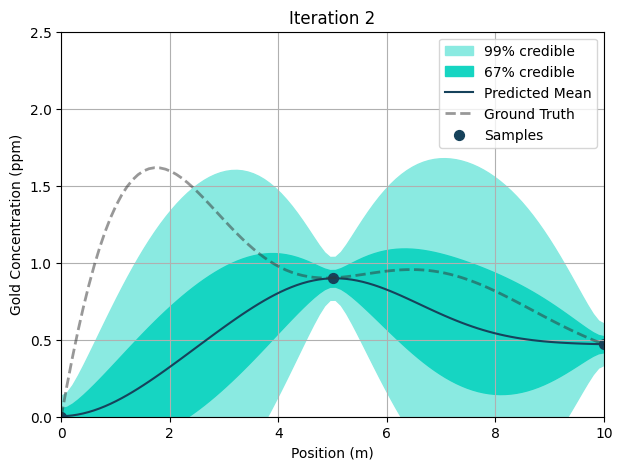

The next should be conducted at 7.500020750428705
The new sample set shows Gold of 0.889 ppm at position 7.5 m
No existing resource named "x_train3" found. Proceeding to upload.
No existing resource named "y_train3" found. Proceeding to upload.
Uploaded data/x_train3.csv as resource "x_train3"
Uploaded data/y_train3.csv as resource "y_train3"
------------------------------------------------------------
ITERATION 3 of 15
------------------------------------------------------------
Training complete of gc_regressor3


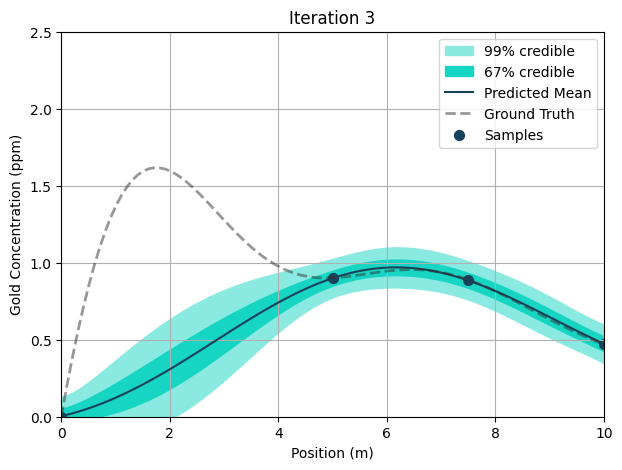

The next should be conducted at 2.197662949063746
The new sample set shows Gold of 1.556 ppm at position 2.198 m
No existing resource named "x_train4" found. Proceeding to upload.
No existing resource named "y_train4" found. Proceeding to upload.
Uploaded data/x_train4.csv as resource "x_train4"
Uploaded data/y_train4.csv as resource "y_train4"
------------------------------------------------------------
ITERATION 4 of 15
------------------------------------------------------------
Training complete of gc_regressor4


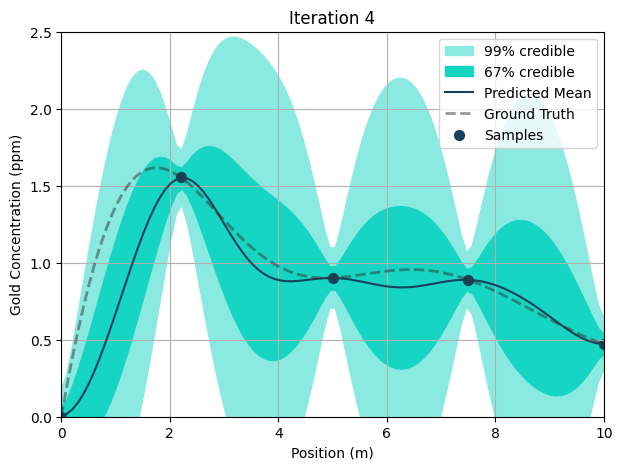

The next should be conducted at 3.598871452276759
The new sample set shows Gold of 1.073 ppm at position 3.599 m
No existing resource named "x_train5" found. Proceeding to upload.
No existing resource named "y_train5" found. Proceeding to upload.
Uploaded data/x_train5.csv as resource "x_train5"
Uploaded data/y_train5.csv as resource "y_train5"
------------------------------------------------------------
ITERATION 5 of 15
------------------------------------------------------------
Training complete of gc_regressor5


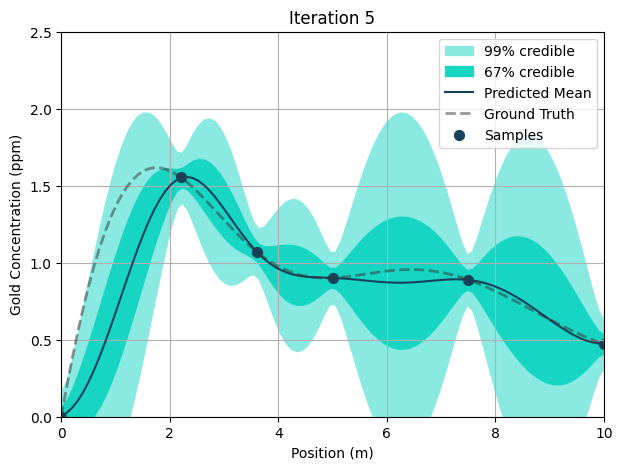

The next should be conducted at 8.750241624603927
The new sample set shows Gold of 0.679 ppm at position 8.75 m
No existing resource named "x_train6" found. Proceeding to upload.
No existing resource named "y_train6" found. Proceeding to upload.
Uploaded data/x_train6.csv as resource "x_train6"
Uploaded data/y_train6.csv as resource "y_train6"
------------------------------------------------------------
ITERATION 6 of 15
------------------------------------------------------------
Training complete of gc_regressor6


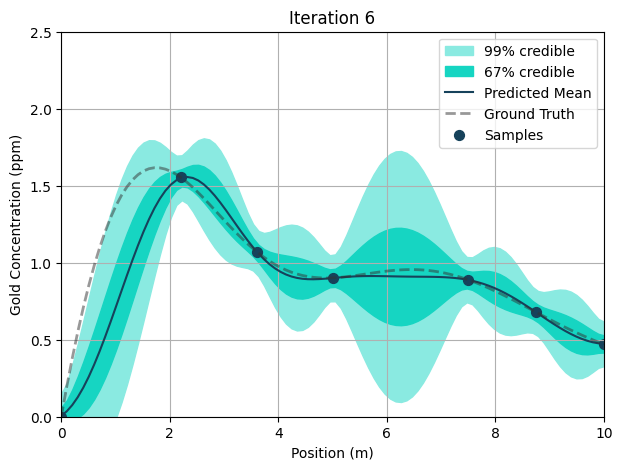

The next should be conducted at 6.233591931396057
The new sample set shows Gold of 0.953 ppm at position 6.234 m
No existing resource named "x_train7" found. Proceeding to upload.
No existing resource named "y_train7" found. Proceeding to upload.
Uploaded data/x_train7.csv as resource "x_train7"
Uploaded data/y_train7.csv as resource "y_train7"
------------------------------------------------------------
ITERATION 7 of 15
------------------------------------------------------------
Training complete of gc_regressor7


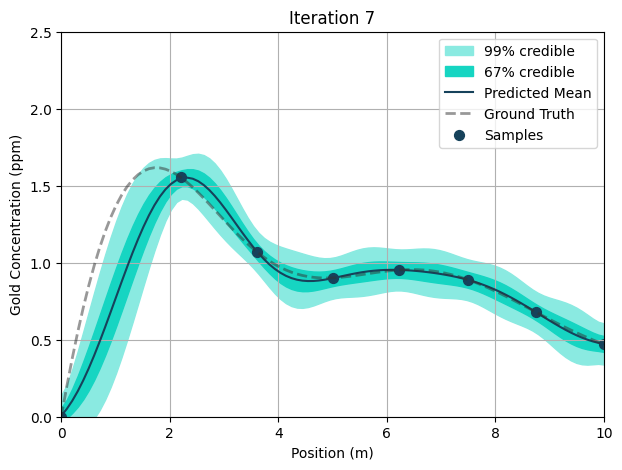

The next should be conducted at 1.017950824501734
The new sample set shows Gold of 1.377 ppm at position 1.018 m
No existing resource named "x_train8" found. Proceeding to upload.
No existing resource named "y_train8" found. Proceeding to upload.
Uploaded data/x_train8.csv as resource "x_train8"
Uploaded data/y_train8.csv as resource "y_train8"
------------------------------------------------------------
ITERATION 8 of 15
------------------------------------------------------------
Training complete of gc_regressor8


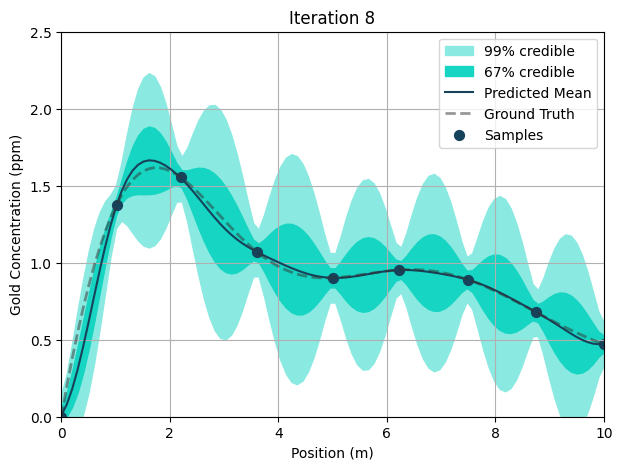

The next should be conducted at 4.29630199535109
The new sample set shows Gold of 0.932 ppm at position 4.296 m
No existing resource named "x_train9" found. Proceeding to upload.
No existing resource named "y_train9" found. Proceeding to upload.
Uploaded data/x_train9.csv as resource "x_train9"
Uploaded data/y_train9.csv as resource "y_train9"
------------------------------------------------------------
ITERATION 9 of 15
------------------------------------------------------------
Training complete of gc_regressor9


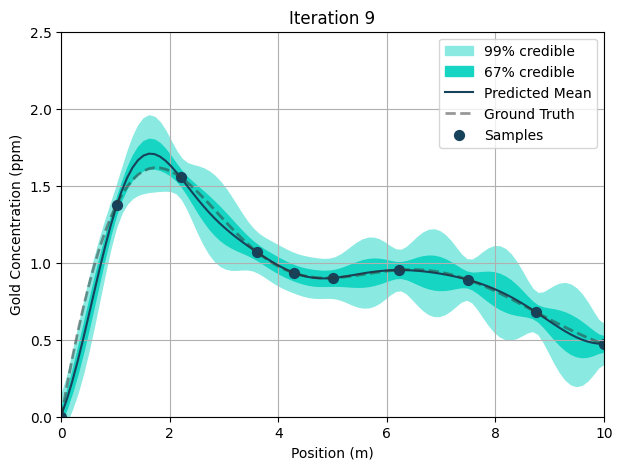

The next should be conducted at 9.404393020715071
The new sample set shows Gold of 0.561 ppm at position 9.404 m
No existing resource named "x_train10" found. Proceeding to upload.
No existing resource named "y_train10" found. Proceeding to upload.
Uploaded data/x_train10.csv as resource "x_train10"
Uploaded data/y_train10.csv as resource "y_train10"
------------------------------------------------------------
ITERATION 10 of 15
------------------------------------------------------------
Training complete of gc_regressor10


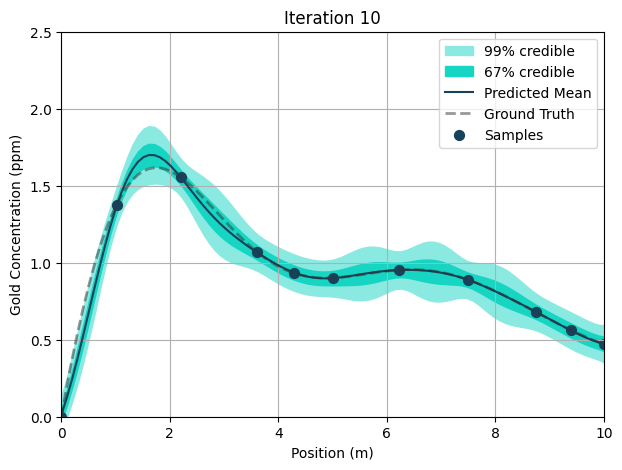

The next should be conducted at 2.868171050940643
The new sample set shows Gold of 1.327 ppm at position 2.868 m
No existing resource named "x_train11" found. Proceeding to upload.
No existing resource named "y_train11" found. Proceeding to upload.
Uploaded data/x_train11.csv as resource "x_train11"
Uploaded data/y_train11.csv as resource "y_train11"
------------------------------------------------------------
ITERATION 11 of 15
------------------------------------------------------------
Training complete of gc_regressor11


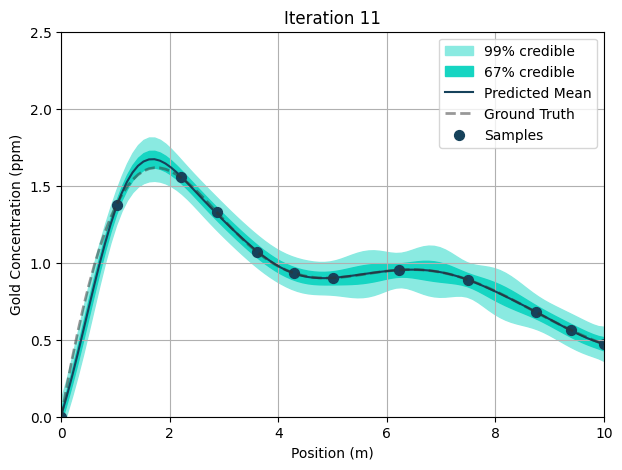

The next should be conducted at 6.867847219950588
The new sample set shows Gold of 0.945 ppm at position 6.868 m
No existing resource named "x_train12" found. Proceeding to upload.
No existing resource named "y_train12" found. Proceeding to upload.
Uploaded data/x_train12.csv as resource "x_train12"
Uploaded data/y_train12.csv as resource "y_train12"
------------------------------------------------------------
ITERATION 12 of 15
------------------------------------------------------------
Training complete of gc_regressor12


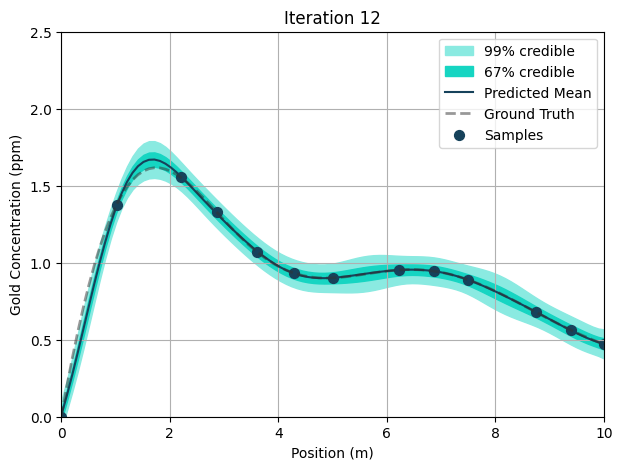

The next should be conducted at 0.4654419583348925
The new sample set shows Gold of 0.795 ppm at position 0.465 m
No existing resource named "x_train13" found. Proceeding to upload.
No existing resource named "y_train13" found. Proceeding to upload.
Uploaded data/x_train13.csv as resource "x_train13"
Uploaded data/y_train13.csv as resource "y_train13"
------------------------------------------------------------
ITERATION 13 of 15
------------------------------------------------------------
Training complete of gc_regressor13


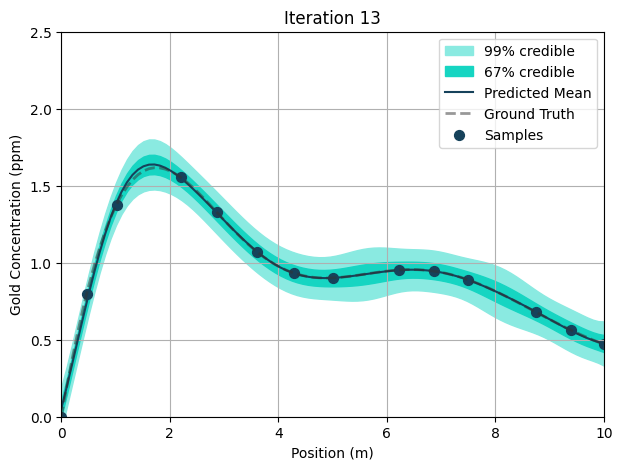

The next should be conducted at 8.130209130226156
The new sample set shows Gold of 0.793 ppm at position 8.13 m
No existing resource named "x_train14" found. Proceeding to upload.
No existing resource named "y_train14" found. Proceeding to upload.
Uploaded data/x_train14.csv as resource "x_train14"
Uploaded data/y_train14.csv as resource "y_train14"
------------------------------------------------------------
ITERATION 14 of 15
------------------------------------------------------------
Training complete of gc_regressor14


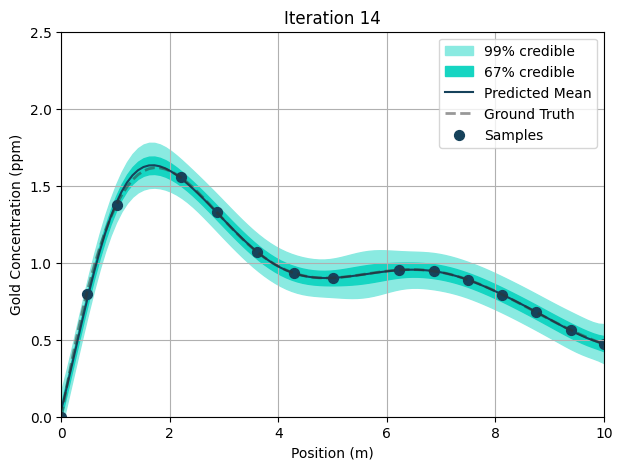

The next should be conducted at 5.6195214069973884
The new sample set shows Gold of 0.927 ppm at position 5.62 m
No existing resource named "x_train15" found. Proceeding to upload.
No existing resource named "y_train15" found. Proceeding to upload.
Uploaded data/x_train15.csv as resource "x_train15"
Uploaded data/y_train15.csv as resource "y_train15"
------------------------------------------------------------
ITERATION 15 of 15
------------------------------------------------------------
Training complete of gc_regressor15


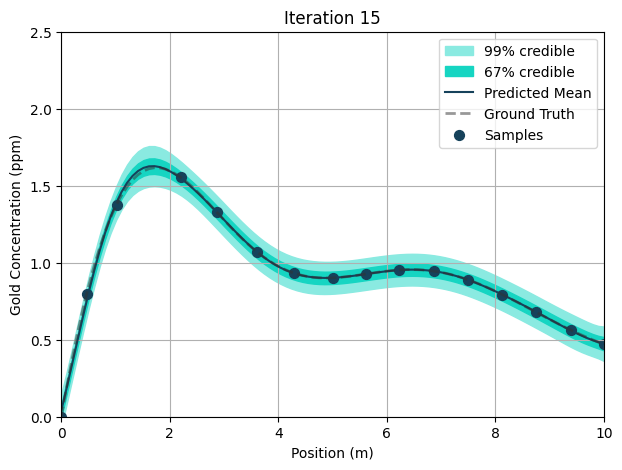

The next should be conducted at 1.5965148694353732
The new sample set shows Gold of 1.608 ppm at position 1.597 m
No existing resource named "x_train16" found. Proceeding to upload.
No existing resource named "y_train16" found. Proceeding to upload.
Uploaded data/x_train16.csv as resource "x_train16"
Uploaded data/y_train16.csv as resource "y_train16"


In [15]:
# Please bear in mind that each iteration may take several minutes...
# This assumes that the first iteration (i.e all cells preivously) have been run successfully
# If you'd like to re-run from the first iteration: change the first argument of range to 1
iteration_start = 2
sample_budget = 15

for iteration in range(iteration_start, sample_budget+1):

    # Demarcate iterations
    print(30*"--")
    print(f"ITERATION {iteration} of {sample_budget}")
    print(30*"--")

    # 1) Train a new GP regressor with the additional sample received

    train_workflow_ph = train_model(
        client=client,
        project_id=project_id,
        iteration=iteration
    )

    # 2) Make predictions with the newly trained model, and visualise the predictions and uncertainty

    predict_workflow_ph = create_visualise_dataset(
        client=client,
        project_id=project_id,
        iteration=iteration,
    )

    samples_x = get_dataset(client, f"x_train{iteration}", PROJECT_NAME)
    samples_y = get_dataset(client, f"y_train{iteration}", PROJECT_NAME)
    visualise_means = get_dataset(client, f"mean_{iteration}", PROJECT_NAME)
    visualise_stds = get_dataset(client, f"std_{iteration}", PROJECT_NAME)
    visualise_inputs = get_dataset(client, "input_space", PROJECT_NAME)

    plot_model_uncertainty(
        samples_x=samples_x,
        samples_y=samples_y,
        visualise_means=visualise_means,
        visualise_stds=visualise_stds,
        visualise_inputs=visualise_inputs,
        iteration=iteration,
        y_bounds=y_bounds,
        with_ground_truth=True,
    )

    # 3) Get a recommendation for the next point to sample based on the trained model and acquisition function
    # NB: the acquisition function can be selected when calling the recommend_new_sample function. By default, it is PosteriorStandardDeviation

    recommendation, recommend_workflow_ph = recommend_new_sample(
        client=client,
        project_id=project_id,
        iteration=iteration,
        acquisition_function="PosteriorStandardDeviation",
    )

    print(f"The next should be conducted at {recommendation}")

    # 4) Take a new sample at the recommended point (in this case, we simply query the ground truth function, but in a real life scenario, this is where an experiment would be conducted)

    new_gold_conc = ground_truth(np.array([recommendation]), noise=False)

    print(f"The new sample set shows Gold of {np.round(new_gold_conc[0], 3)} ppm at position {np.round(recommendation, 3)} m")

    # 5) Add the new sample to the existing dataset of samples acquired thus far

    add_new_sample(
        client=client,
        new_x=recommendation,
        new_y=new_gold_conc[0],
        iteration=iteration+1,
        project_name=PROJECT_NAME,
    )

--------------------
**Active Learning Evolution Example**

The GIF below illustrates how active learning evolves over time in this example.

**Comments**

- The resulting fit is highly flexible. The Gaussian Process does not assume a fixed functional form for the underlying data, aside from smoothness
- New samples are selected at points of highest posterior uncertainty. This is one of several possible active learning strategies, determined by the chosen acquisition function. The choice of acquisition depends on the objective of the experimental campaign—for example, optimisation (finding a maximum or minimum) or maximising global information gain.
- In this 1D example, the sampling strategy may seem intuitive—selecting new points where model uncertainty is greatest. However, in higher-dimensional problems (which are more typical in real-world applications), this process becomes significantly less interpretable. The approach demonstrated here generalises beyond one-dimensional inputs.
--------------------
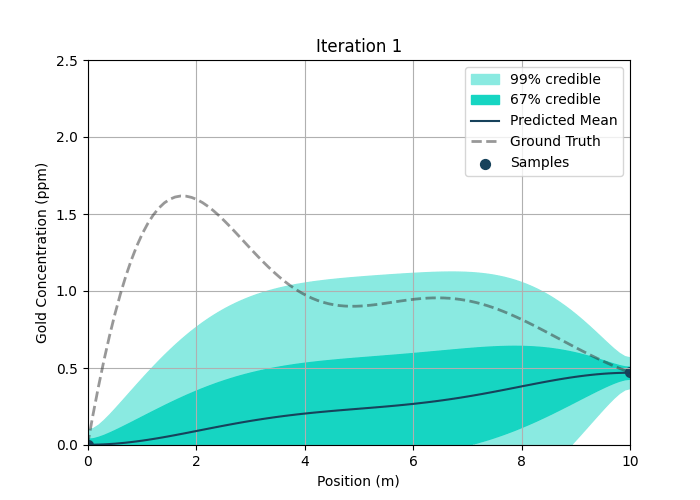